> **Note:** This is the full exploratory notebook preserving the investigation trail (failed hybrid, $\theta$-$m$ diagnosis, $p$-bucket tests, age-$m$ analysis). For the streamlined presentation of the findings, see **`TM_MC_Marginal_Utility_Convergence_revised.ipynb`**.

# Marginal utility under Harmenberg TM vs Monte Carlo

This notebook is **self-contained**: read **Part I (theory)** first, then run the code for **Part II (numerical experiments)**, **Part III (covariance debias)**, and **Part IV (diagnosis of why the hybrid fails)**.

---

## Part I — Mathematical background: $p$-linear TM vs the joint of $(p,m)$

### Harmenberg’s identity and what the TM version computes

Under Harmenberg’s neutral measure (see BST **`ApndxHarKmenberg`**, section **“Harmenberg’s Method”** and Theorem 1, and `history/20260331-mathematical-derivations-harmenberg.md` **§1–12**), aggregates that enter the objective **linearly in permanent income** $p$ admit a **factorization**:

$$
\mathbb{E}_P\bigl[p\,f(m,j)\bigr] = \mathbb{E}_P[p]\,\mathbb{E}_Q\bigl[f(m,j)\bigr],
$$

where $Q$ is the permanent-income–weighted (“neutral”) measure on the Markov states $(m,j)$. The **transition-matrix (TM)** implementation in HAFiscal exploits exactly this structure for **$p$-linear** objects (consumption levels, multipliers, NPVs built from $p\cdot(\cdot)$).

### When the TM method (as implemented) is **not** exact: nonlinear $p$

`ApndxHarKmenberg` also has a section **“When the Joint Distribution Is Required”**; the same point is developed in **§13** of `history/20260331-mathematical-derivations-harmenberg.md`. The key idea:

- If the statistic is **not** linear in $p$ — e.g. welfare from $u(c)$ with $u$ nonlinear, variances/Gini, or here **marginal utility** $u'(c_{\mathrm{lvl}})=c_{\mathrm{lvl}}^{-\rho}$ when $c_{\mathrm{lvl}}$ depends on $p$ in a way that makes $u'$ **nonlinear in $p$** — then you need the **joint** distribution of $(p,m,j,\ldots)$ under the physical measure $P$.
- A TM that only carries **$\pi(m,j)$** and then multiplies by a **marginal** law for $p$ **as if** $p\perp(m,j)$ uses a **product measure**. That coincides with $\mathbb{E}_P[\cdot]$ only for functionals where factorization is exact (the $p$-linear case). For nonlinear $p$, there is a **structural bias** that **does not vanish** by refining the $m$-grid alone; grid refinement only controls discretization error **within** that approximate object.

**Further reading:** `ApndxHarKmenberg` **“The Covariance Kernel and 1D Computability”** and **“Higher-Order Moments”**; math-derive **§14** (covariance corrections for moving between $P$ and $Q$).

### Why **MC-P** and **MC-Q** can target the right object

- **MC-P (physical measure):** the simulation stores **each agent’s** normalized wealth and permanent income (e.g. `mNrm`, `pLvl`) **jointly** along the path. The cross-sectional mean of $u'(c_{\mathrm{lvl},\mathrm{splurge}})$ is an empirical average under the **empirical joint**; with long burn-in, long horizon, and large $N$, it converges (ergodic MC logic) to $\mathbb{E}_P[u']$.
- **MC-Q (Harmenberg / dual reconstruction):** with `DualAggFiscalType`, the same simulated **joint** states support reconstruction of objects under the neutral measure where appropriate. Crucially, for **nonlinear** functionals of $(p,m)$, both MC variants **still see the simulated joint**; the limitation in this notebook is the **TM** side, which uses an **independent-$p$ augmentation** on top of a 2D $(m,j)$ chain (see `verify_four_methods_agreement.py` / `compute_pLvl_distribution`).

### Object studied here

Splurge consumption is **level** $c_{\mathrm{lvl}} = p\cdot X(m,j)$, so

$$
u'(c_{\mathrm{lvl}}) = p^{-\rho}\,X(m,j)^{-\rho},
$$

a **product** $A(p)\,B(m,j)$ under the true joint. The **naive TM** estimator used below computes $\mathbb{E}_w[p^{-\rho}]\,\mathbb{E}_\pi[X^{-\rho}]$ (marginal $w$ for $p$ × ergodic $\pi$ on $(m,j)$), i.e. it **drops** $\mathrm{Cov}_P(p^{-\rho},X^{-\rho})$. **Part II** chooses MC sample size and TM grid resolution so this **misspecification shows up as a TM–MC gap** that exceeds **about $3\times\mathrm{SE}$** of the MC reference at the **calibrated** population size $N_{\mathrm{cal}}$ (across seeds). **Part III** adds a **covariance correction** estimated from MC. **Part IV** diagnoses why the hybrid makes things *worse* and develops two complementary fixes: (1) a **covariance kernel** that resolves the $\theta$--$m$ coupling in the splurge (the dominant error, $\sim$6\% of $\mathbb{E}[B]$), and (2) **$p$-buckets** that capture the small but real $p$--$m$ correlation from the $\psi$-channel ($\sim$0.4\%, the same structural effect as in `ApndxHarKmenberg`).

---

### Scope and reproduction

- **Education:** single type — **high school** (`EDUC = "highschool"` via `_build_single_type_economy`), not the full three-way population mix in the paper.
- **Environment:** project `uv` env; first code cell `chdir`s to `FromPandemicCode`.
- **Re-run all outputs from the shell** (from repo root):

```bash
cd Code/HA-Models
MPLBACKEND=Agg uv run jupyter nbconvert --to notebook --execute TM_MC_Marginal_Utility_Convergence.ipynb --output TM_MC_Marginal_Utility_Convergence.ipynb
```

Add `--ExecutePreprocessor.timeout=1200` if needed. **VS Code:** enable `notebook.markdown.math.enabled` if equations show as plain text.

---
**Next:** run the cells below (imports → helpers → parameters), then **Part II**.


### Why TM-init MC uses a **warmup** (`_mc_burnin_tm_init`)

The TM side tracks **$(m,j)$** on a grid; **`pLvl` is not a TM state.** TM-init MC therefore samples `(m,j)` from the TM ergodic and draws **`pLvl` from a separate recipe** (marginal for `p`, not the true joint with the drawn `j`). Under `sim_one_period`, **$p$ and $j$ interact** every period, so the cross-section **continues to adjust** after the draw. The **warmup** is inner `sim_one_period` steps so the **joint** empirical distribution of $(p,m,j)$ moves **closer** to what full MC dynamics imply before the main experiment — especially for objects nonlinear in $(p,m)$ (e.g. marginal utility here). This is the same structural point as in **`pLvl_TM_init_ergodic_gap.ipynb`** and the Gatekeeper note on burn-in.

**Not** primarily “recession vs non-recession”: baseline TM and this warmup are **normal-times (`base`)** objects.

In [1]:
import os
import sys
import warnings
from copy import deepcopy

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

_here = os.path.abspath(os.getcwd())
_candidates = [
    os.path.join(_here, "FromPandemicCode"),
    os.path.join(os.path.dirname(_here), "FromPandemicCode"),
    _here,
]
_FPC = None
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "verify_four_methods_agreement.py")):
        _FPC = _p
        break
if _FPC is None:
    raise FileNotFoundError(
        "Could not find FromPandemicCode/verify_four_methods_agreement.py; "
        f"tried {_candidates}"
    )
os.chdir(_FPC)
if _FPC not in sys.path:
    sys.path.insert(0, _FPC)
_HM = os.path.dirname(_FPC)
if _HM not in sys.path:
    sys.path.insert(0, _HM)

print("FromPandemicCode:", _FPC)

FromPandemicCode: /home/shared/github/llorracc/HAFiscal-Latest/Code/HA-Models/FromPandemicCode


In [2]:
import contextlib
import io

_argv = sys.argv[:]
sys.argv = [sys.argv[0], "1.01", "2.0", "0.7"]

# AggFiscalModel calls return_parameters() at import time; Parameters prints all
# three education groups. Silence that stdout so this notebook only *uses* high
# school (see EDUC below) without cluttering output.
import Parameters as _HAFiscal_parameters

_rp_orig = _HAFiscal_parameters.return_parameters


def _return_parameters_quiet(*args, **kwargs):
    _buf = io.StringIO()
    with contextlib.redirect_stdout(_buf):
        return _rp_orig(*args, **kwargs)


_HAFiscal_parameters.return_parameters = _return_parameters_quiet

from tm_methods import (
    build_tm_agg_fiscal,
    compute_pLvl_distribution,
    find_ergodic_distribution,
)

from verify_four_methods_agreement import (
    HAS_DUAL,
    _build_single_type_economy,
    _fix_act_T_after_switch,
    _mc_burnin_tm_init,
    _mc_mean_marginal_utility_path,
    mean_marginal_utility_tm_independent_p,
)
from AggFiscalModel import DualAggFiscalType

sys.argv = _argv

if not HAS_DUAL:
    raise RuntimeError("DualAggFiscalType required for this notebook.")

In [3]:
def tm_ergodic_for_mu(tm_data: dict) -> np.ndarray:
    ce = tm_data.get("cohort_ergodic")
    if ce is not None and np.sum(np.asarray(ce, dtype=float)) > 0:
        return np.asarray(ce, dtype=float).ravel()
    return np.asarray(find_ergodic_distribution(tm_data["TranMatrix"]), dtype=float).ravel()


def tm_mean_mu_curve(
    agent,
    m_counts,
    CRRA: float,
    neutral_measure: bool,
    n_p_points: int = 120,
):
    """Deterministic TM mean MU for each mCount (same solved agent)."""
    mus = []
    for m in m_counts:
        tm_data = build_tm_agg_fiscal(
            agent, mCount=int(m), Cratio=1.0, neutral_measure=neutral_measure
        )
        erg = tm_ergodic_for_mu(tm_data)
        mus.append(
            mean_marginal_utility_tm_independent_p(
                agent, tm_data, erg, CRRA, n_p_points=n_p_points
            )
        )
    return np.array(mus, dtype=float)


def mc_se_median_first_diff(mu_paths: np.ndarray, t_start: int) -> float:
    """
    For each time t > t_start, across-seed SE of the one-period change in the
    cross-sectional mean marginal utility. Return the median of those SE_t.

    This targets "how much the MC estimate moves" period-to-period, not the SE
    of a single long-run average across all simulation dates (which mixes
    non-stationary burn-in if t_start is too small).
    """
    mu_paths = np.asarray(mu_paths, dtype=float)
    if mu_paths.ndim != 2:
        raise ValueError(mu_paths.shape)
    s, big_t = mu_paths.shape
    ts = int(t_start)
    if s < 2 or big_t < ts + 2:
        return float("nan")
    d = np.diff(mu_paths[:, ts:], axis=1)
    se_t = np.std(d, axis=0, ddof=1) / np.sqrt(s)
    return float(np.median(se_t))


def mc_mean_mu_once(
    *,
    educ: str,
    agent_count: int,
    seed: int,
    periods: int,
    warmup: int,
    t_start: int,
):
    """
    One MC-P run: TM-ergodic init + warmup + run_experiment.

    Returns (mean_mu_tail, CRRA, mu_path) where mean_mu_tail is the mean of
    cross-sectional mean u'(t) over dates t >= t_start (inclusive).
    """
    economy, base_dict = _build_single_type_economy(
        educ=educ,
        agent_count=agent_count,
        seed=seed,
        act_T=periods,
        agent_cls=DualAggFiscalType,
    )
    economy.solve()
    CRRA = float(economy.agents[0].CRRA)

    _mc_burnin_tm_init(
        economy, warmup=warmup, neutral_measure=True, use_dual=True
    )
    economy.save_state()
    economy.switch_to_counterfactual_mode("base")
    _fix_act_T_after_switch(economy, periods)
    economy.make_idiosyncratic_shock_histories()
    mc_res = economy.run_experiment(**deepcopy(base_dict), Full_Output=True)

    mu_path = np.asarray(
        _mc_mean_marginal_utility_path(mc_res["cLvl_all_splurge"], CRRA),
        dtype=float,
    ).ravel()
    ts = int(t_start)
    tail = mu_path[ts:]
    mean_mu = float(np.mean(tail)) if tail.size else float("nan")
    return mean_mu, CRRA, mu_path


## Part II — Numerical experiments: $N$, grid quality, and statistical detectability

**Goal:** illustrate the theory above by **measuring** mean marginal utility $\mathbb{E}[u'(c_{\mathrm{Lvl,splurge}})]$ with:

1. **MC-P** at several population sizes $N$ and **independent random seeds**, so Monte Carlo uncertainty shrinks like $\sim 1/\sqrt{N}$ (and across-seed dispersion estimates sampling error).
2. **TM-P and TM-Q** at several wealth-grid resolutions `mCount` (deterministic given the solved policy), so you see **TM’s own** limit as the grid tightens — **not** the same as $\mathbb{E}_P[u']$ when the TM uses **independent $p$**.
3. A **calibration search** over `N_LIST` (increasing $N$): at each $N$ we compare TM-P and TM-Q at the **largest** `mCount` in `M_COUNTS` to the MC **tail-mean** $\hat\mu$ ( $t\geq$`T_START_MC` ) across seeds. The **first** $N$ for which **both** TM measures differ from $\hat\mu$ by more than $3\times\mathrm{SE}_{\mathrm{change}}$ (median over time of across-seed SE of $\Delta\mu_t$, see code) is stored as $N_{\mathrm{cal}}$; $m_{\mathrm{cal}}=\max(\texttt{M\_COUNTS})$. **`CALIB`** holds $\hat\mu$, `se_ref` $=\mathrm{SE}_{\mathrm{change}}$, and `se_level`. **`COMPLETE_N_LIST_FOR_FIGS`** fills all `N_LIST` points for **II.1**. **Named figures:** `FIGS["II_1_mcpu_vs_agentcount"]`, `FIGS["diag_mcpu_path_Ncal"]`, `FIGS["II_2_tm_mc_vs_mcount"]`, `FIGS["II_3_tm_mc_band_gaps"]`, `FIGS["diag_cov_path_cal"]`, `FIGS["III_hybrid_comparison"]`.

**Parameters:** reduce `N_LIST`, `M_COUNTS`, or `SEEDS` for a faster smoke test; defaults are modest but can take several minutes.


In [4]:
# Single education type only (not a population mix of dropout / HS / college)
EDUC = "highschool"
PERIODS = 100
WARMUP = 24

# Stationary tail for MC *level* summaries and for change-SE (first differences
# use mu(t)-mu(t-1) only for t > T_START_MC). Increase if you need a longer
# post–near-ergodic window after mechanical burn-in.
T_START_MC = max(PERIODS // 2, 1)

N_LIST = np.array([2_000, 5_000, 10_000, 20_000], dtype=int)
M_COUNTS = np.array([40, 70, 100, 150], dtype=int)

SEEDS = np.array([41, 42, 43, 44, 45], dtype=int)
N_P_POINTS = 120

# Figure handles (name -> matplotlib Figure). Use FIGS["..."] instead of cell numbers.
FIGS: dict = {}

# After calibration, optionally skip larger N to save time; II.1 still needs
# several AgentCount values on the x-axis:
COMPLETE_N_LIST_FOR_FIGS = True  # fill every N in N_LIST for the II.1 figure

# After TM−MC gap exceeds 3·SE_change (both TM-P and TM-Q), stop MC runs unless:
PART_II_FULL_SWEEP = False  # True: same as filling all N during calibration loop

print("N_LIST:", N_LIST.tolist())
print("M_COUNTS:", M_COUNTS.tolist())
print("SEEDS:", SEEDS.tolist())
print("T_START_MC (MC tail / change-SE):", T_START_MC)


N_LIST: [2000, 5000, 10000, 20000]
M_COUNTS: [40, 70, 100, 150]
SEEDS: [41, 42, 43, 44, 45]
T_START_MC (MC tail / change-SE): 50


### II.1 — MC-P reference vs population size $N$

Larger `AgentCount` shrinks **simulation noise** on the cross-sectional mean of $u'$ each period. Each seed contributes one **tail time-mean** $\hat\mu_s = (T-T_{\mathrm{start}})^{-1}\sum_{t\geq T_{\mathrm{start}}} \mu_{s,t}$ with $T_{\mathrm{start}}=$ `T_START_MC` (defaults to `max(PERIODS//2,1)`), so early simulation dates that may still reflect **transient** dynamics are excluded from the level used for TM comparison.

The **error bars** in the next figure use **across-seed** dispersion of those tail-means: $\mathrm{SE}_{\mathrm{level}} \approx s/\sqrt{S}$. That is **not** the same object as $\mathrm{SE}_{\mathrm{change}}$ used for the **II.3** band (median over $t>T_{\mathrm{start}}$ of across-seed SE of $\mu_{s,t}-\mu_{s,t-1}$); see the **`diag_mcpu_path_Ncal`** figure and `CALIB`.

`COMPLETE_N_LIST_FOR_FIGS` (default **True**) fills every $N\in$`N_LIST` for this plot even if calibration stopped early. **Figure handle:** `FIGS["II_1_mcpu_vs_agentcount"]` (also `fig.number` / `num="II_1_mcpu_vs_agentcount"`).


In [5]:
econ_ref, _ = _build_single_type_economy(
    educ=EDUC,
    agent_count=1000,
    seed=0,
    act_T=PERIODS,
    agent_cls=DualAggFiscalType,
)
econ_ref.solve()
agent_ref = econ_ref.agents[0]
CRRA_tm = float(agent_ref.CRRA)

mu_tm_p = tm_mean_mu_curve(
    agent_ref, M_COUNTS, CRRA_tm, neutral_measure=False, n_p_points=N_P_POINTS
)
mu_tm_q = tm_mean_mu_curve(
    agent_ref, M_COUNTS, CRRA_tm, neutral_measure=True, n_p_points=N_P_POINTS
)

for i, m in enumerate(M_COUNTS):
    print(
        f"mCount={m:3d}  TM-P mu={mu_tm_p[i]:.6e}  TM-Q mu={mu_tm_q[i]:.6e}"
    )


mCount= 40  TM-P mu=1.238251e-02  TM-Q mu=1.240250e-02
mCount= 70  TM-P mu=1.236346e-02  TM-Q mu=1.238328e-02
mCount=100  TM-P mu=1.235863e-02  TM-Q mu=1.237841e-02
mCount=150  TM-P mu=1.235615e-02  TM-Q mu=1.237592e-02


In [6]:
mc_by_n = {}
crra_ref = None
MC_PATHS_NCAL = None

n_order = np.sort(N_LIST.astype(int))

N_CAL = None
M_CAL = None
CALIB_SATISFIED = False
SE_MULT = 3.0

for n in n_order:
    mc_by_n[int(n)] = []
    paths_n = []
    for sd in SEEDS:
        mu, crra, path = mc_mean_mu_once(
            educ=EDUC,
            agent_count=int(n),
            seed=int(sd),
            periods=PERIODS,
            warmup=WARMUP,
            t_start=T_START_MC,
        )
        mc_by_n[int(n)].append(mu)
        paths_n.append(path)
        crra_ref = crra

    M = np.stack(paths_n, axis=0)
    ref_vals_n = np.array(mc_by_n[int(n)], dtype=float)
    mu_ref_n = float(np.mean(ref_vals_n))
    se_level_n = float(np.std(ref_vals_n, ddof=1) / np.sqrt(len(SEEDS)))
    se_chg_n = mc_se_median_first_diff(M, T_START_MC)

    j_hi = len(M_COUNTS) - 1
    gp = abs(float(mu_tm_p[j_hi]) - mu_ref_n)
    gq = abs(float(mu_tm_q[j_hi]) - mu_ref_n)
    if gp > SE_MULT * se_chg_n and gq > SE_MULT * se_chg_n:
        N_CAL = int(n)
        M_CAL = int(M_COUNTS[j_hi])
        CALIB_SATISFIED = True
        MC_PATHS_NCAL = M
        break

if N_CAL is None:
    N_CAL = int(N_LIST.max())
    M_CAL = int(M_COUNTS.max())
    print(
        "WARNING: No (N, mCount) in grids satisfied |TM−MC| > 3·SE_change for both TM-P and TM-Q; "
        f"using N={N_CAL}, mCount={M_CAL}."
    )

if PART_II_FULL_SWEEP:
    for n in n_order:
        if int(n) in mc_by_n and len(mc_by_n[int(n)]) == len(SEEDS):
            continue
        mc_by_n[int(n)] = []
        for sd in SEEDS:
            mu, crra, path = mc_mean_mu_once(
                educ=EDUC,
                agent_count=int(n),
                seed=int(sd),
                periods=PERIODS,
                warmup=WARMUP,
                t_start=T_START_MC,
            )
            mc_by_n[int(n)].append(mu)
            crra_ref = crra

if COMPLETE_N_LIST_FOR_FIGS:
    for n in n_order:
        if int(n) in mc_by_n and len(mc_by_n[int(n)]) == len(SEEDS):
            continue
        mc_by_n[int(n)] = []
        for sd in SEEDS:
            mu, crra, path = mc_mean_mu_once(
                educ=EDUC,
                agent_count=int(n),
                seed=int(sd),
                periods=PERIODS,
                warmup=WARMUP,
                t_start=T_START_MC,
            )
            mc_by_n[int(n)].append(mu)
            crra_ref = crra

if MC_PATHS_NCAL is None:
    paths_n = []
    for sd in SEEDS:
        mu, crra, path = mc_mean_mu_once(
            educ=EDUC,
            agent_count=int(N_CAL),
            seed=int(sd),
            periods=PERIODS,
            warmup=WARMUP,
            t_start=T_START_MC,
        )
        paths_n.append(path)
    MC_PATHS_NCAL = np.stack(paths_n, axis=0)

ref_vals = np.array(mc_by_n[N_CAL], dtype=float)
mu_ref = float(np.mean(ref_vals))
se_level = float(np.std(ref_vals, ddof=1) / np.sqrt(len(SEEDS)))
se_ref = mc_se_median_first_diff(MC_PATHS_NCAL, T_START_MC)

CALIB = {
    "N_CAL": N_CAL,
    "M_CAL": M_CAL,
    "SE_MULT": SE_MULT,
    "mu_ref": mu_ref,
    "se_ref": se_ref,
    "se_level": se_level,
    "satisfied": CALIB_SATISFIED,
}

N_plot = np.sort(np.array(list(mc_by_n.keys()), dtype=int))
mc_mean = np.array([np.mean(mc_by_n[int(n)]) for n in N_plot])
mc_std = np.array([np.std(mc_by_n[int(n)], ddof=1) for n in N_plot])
mc_se = mc_std / np.sqrt(len(SEEDS))

n_ref = N_CAL

print("CALIB (stored for Part II.3–III):", CALIB)
print(
    "  se_ref = median_t SE across seeds of Δ(mean u'), t>T_START_MC; "
    "se_level = SE across seeds of tail-mean u'"
)
print("CRRA =", crra_ref)
assert abs(float(agent_ref.CRRA) - float(crra_ref)) < 1e-9, (
    float(agent_ref.CRRA),
    crra_ref,
)
for i, n in enumerate(N_plot):
    print(
        f"N={n:6d}  tail-mean(mu)={mc_mean[i]:.6e}  across-seed SE(level)={mc_se[i]:.6e}"
    )


CALIB (stored for Part II.3–III): {'N_CAL': 2000, 'M_CAL': 150, 'SE_MULT': 3.0, 'mu_ref': 0.012874109953296664, 'se_ref': 9.228630468982946e-05, 'se_level': 0.00010289239983193373, 'satisfied': True}
  se_ref = median_t SE across seeds of Δ(mean u'), t>T_START_MC; se_level = SE across seeds of tail-mean u'
CRRA = 2.0
N=  2000  tail-mean(mu)=1.287411e-02  across-seed SE(level)=1.028924e-04
N=  5000  tail-mean(mu)=1.299394e-02  across-seed SE(level)=1.521425e-04
N= 10000  tail-mean(mu)=1.288822e-02  across-seed SE(level)=7.745220e-06
N= 20000  tail-mean(mu)=1.289691e-02  across-seed SE(level)=1.972191e-05


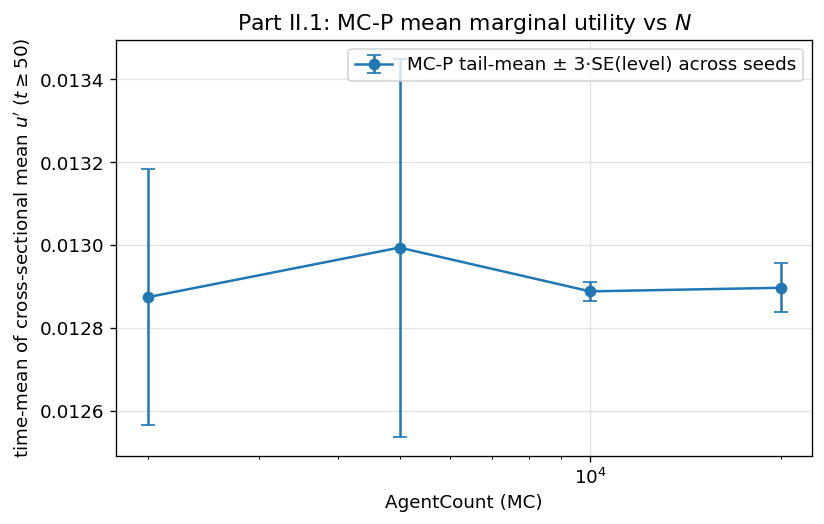

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5), num="II_1_mcpu_vs_agentcount")
ax.errorbar(
    N_plot,
    mc_mean,
    yerr=3 * mc_se,
    fmt="-o",
    capsize=4,
    label="MC-P tail-mean ± 3·SE(level) across seeds",
)
ax.set_xlabel("AgentCount (MC)")
ax.set_ylabel(
    rf"time-mean of cross-sectional mean $u'$ ($t \geq {T_START_MC}$)"
)
ax.set_xscale("log")
ax.set_title("Part II.1: MC-P mean marginal utility vs $N$")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
FIGS["II_1_mcpu_vs_agentcount"] = fig
plt.show()


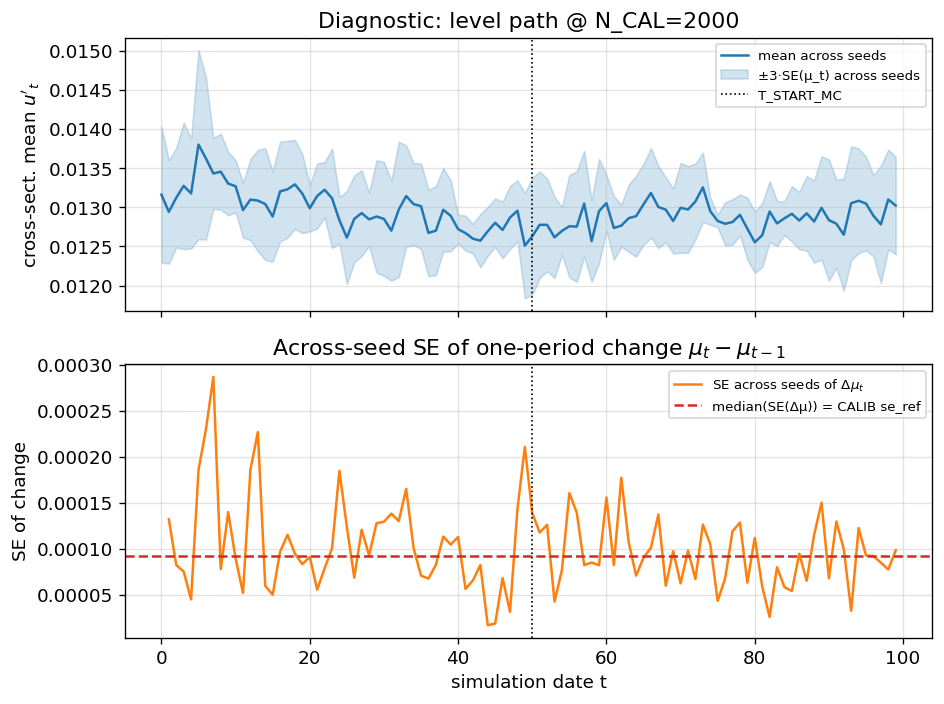

In [8]:
# Cross-seed path of the cross-sectional mean u'(t) at N_CAL (level noise)
P = MC_PATHS_NCAL
tix = np.arange(P.shape[1])
m_mu = np.mean(P, axis=0)
se_mu_t = np.std(P, axis=0, ddof=1) / np.sqrt(P.shape[0])
dpath = np.diff(P, axis=1)
se_d_t = np.std(dpath, axis=0, ddof=1) / np.sqrt(P.shape[0])
t_d = np.arange(1, P.shape[1])

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, num="diag_mcpu_path_Ncal"
)
ax0.plot(tix, m_mu, color="C0", label="mean across seeds")
ax0.fill_between(
    tix,
    m_mu - 3 * se_mu_t,
    m_mu + 3 * se_mu_t,
    color="C0",
    alpha=0.2,
    label="±3·SE(μ_t) across seeds",
)
ax0.axvline(T_START_MC, color="k", ls=":", lw=1, label="T_START_MC")
ax0.set_ylabel(r"cross-sect. mean $u'_t$")
ax0.set_title(f"Diagnostic: level path @ N_CAL={N_CAL}")
ax0.legend(loc="best", fontsize=8)
ax0.grid(True, alpha=0.35)

ax1.plot(t_d, se_d_t, color="C1", label=r"SE across seeds of $\Delta\mu_t$")
ax1.axhline(se_ref, color="C3", ls="--", label="median(SE(Δμ)) = CALIB se_ref")
ax1.axvline(T_START_MC, color="k", ls=":", lw=1)
ax1.set_xlabel("simulation date t")
ax1.set_ylabel("SE of change")
ax1.set_title(r"Across-seed SE of one-period change $\mu_t-\mu_{t-1}$")
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, alpha=0.35)
plt.tight_layout()
FIGS["diag_mcpu_path_Ncal"] = fig
plt.show()


### II.2 — TM-P and TM-Q vs wealth grid (`mCount`)

The transition matrix is built on a discretized $m$-grid (`build_tm_agg_fiscal`, `mCount`). Conditional on the **same** solved `DualAggFiscalType`, TM mean marginal utility is **deterministic** in the seed (no MC draw in the TM step itself). As `mCount` increases, TM values settle toward the **TM-defined** estimand (product measure for $p$ × $\pi(m,j)$), **not** necessarily toward the MC-P joint limit.

Horizontal lines: **MC-P tail-mean** of the same object at $N_{\mathrm{cal}}$ (and at $N_{\max}$ when it differs). **Figure handle:** `FIGS["II_2_tm_mc_vs_mcount"]`.

**Note:** Solution and policy are **independent** of MC `AgentCount`; only MC noise depends on $N$.


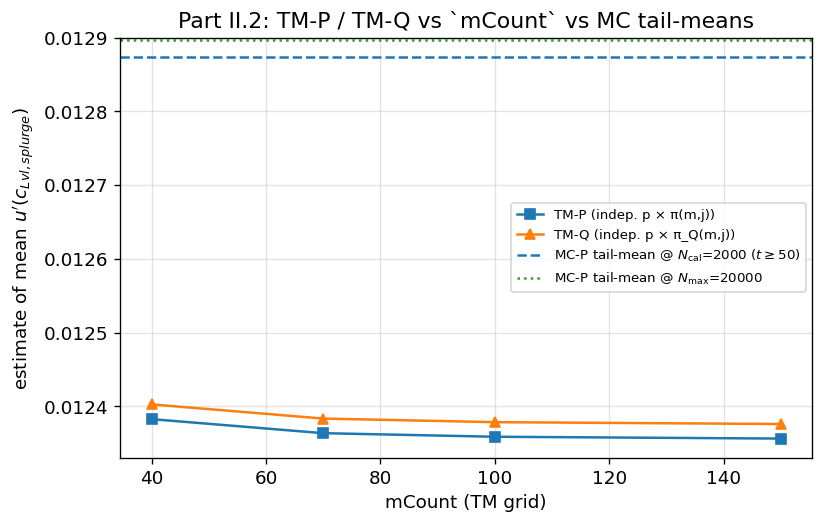

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5), num="II_2_tm_mc_vs_mcount")
ax.plot(M_COUNTS, mu_tm_p, "-s", label="TM-P (indep. p × π(m,j))")
ax.plot(M_COUNTS, mu_tm_q, "-^", label="TM-Q (indep. p × π_Q(m,j))")
ax.axhline(
    mu_ref,
    color="C0",
    ls="--",
    lw=1.5,
    label=rf"MC-P tail-mean @ $N_{{\mathrm{{cal}}}}$={n_ref} ($t \geq {T_START_MC}$)",
)
if int(N_LIST.max()) in mc_by_n and int(N_LIST.max()) != int(n_ref):
    ax.axhline(
        float(np.mean(mc_by_n[int(N_LIST.max())])),
        color="C2",
        ls=":",
        lw=1.5,
        label=rf"MC-P tail-mean @ $N_{{\max}}$={int(N_LIST.max())}",
    )
ax.set_xlabel("mCount (TM grid)")
ax.set_ylabel(r"estimate of mean $u'(c_{Lvl,splurge})$")
ax.set_title("Part II.2: TM-P / TM-Q vs `mCount` vs MC tail-means")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.35)
plt.tight_layout()
FIGS["II_2_tm_mc_vs_mcount"] = fig
plt.show()


### II.3 — Gaps: TM minus MC band

We use the **stored** MC **tail-mean** $\hat\mu$ at **`CALIB["N_CAL"]`** (same $t\geq$`T_START_MC` window as above). The **shaded band** is $\pm 3\,\mathrm{SE}_{\mathrm{change}}$ where $\mathrm{SE}_{\mathrm{change}}$ is **`CALIB["se_ref"]`**: the **median** over dates $t>T_{\mathrm{start}}$ of the across-seed standard error of the **one-period change** $\mu_{s,t}-\mu_{s,t-1}$ in the cross-sectional mean marginal utility. That targets **how much the MC estimate moves** period-to-period after the transient window (useful when debugging time paths and hybrid/covariance dynamics), **not** $\mathrm{SE}_{\mathrm{level}}$ of the long tail-mean (`CALIB["se_level"]`).

**Figure handle:** `FIGS["II_3_tm_mc_band_gaps"]`.


In [10]:
n_ref = int(CALIB["N_CAL"])
mu_ref = float(CALIB["mu_ref"])
se_ref = float(CALIB["se_ref"])
se_level = float(CALIB["se_level"])
ref_vals = np.array(mc_by_n[n_ref], dtype=float)

gap_p = mu_tm_p - mu_ref
gap_q = mu_tm_q - mu_ref
rel_p = 100.0 * gap_p / mu_ref
rel_q = 100.0 * gap_q / mu_ref

print(
    f"MC reference (calibrated N={n_ref}, tail t>={T_START_MC}): mean(mu)={mu_ref:.6e}"
)
print(f"  SE(level) across seeds of tail-mean: {se_level:.6e}")
print(f"  SE(change) median_t SE(Δμ) across seeds, t>{T_START_MC}: {se_ref:.6e}")
print("TM − MC (absolute):", gap_p)
print("TM − MC (% of ref):", rel_p)


MC reference (calibrated N=2000, tail t>=50): mean(mu)=1.287411e-02
  SE(level) across seeds of tail-mean: 1.028924e-04
  SE(change) median_t SE(Δμ) across seeds, t>50: 9.228630e-05
TM − MC (absolute): [-0.0004916  -0.00051065 -0.00051548 -0.00051796]
TM − MC (% of ref): [-3.81854797 -3.96645164 -4.00401492 -4.02326517]


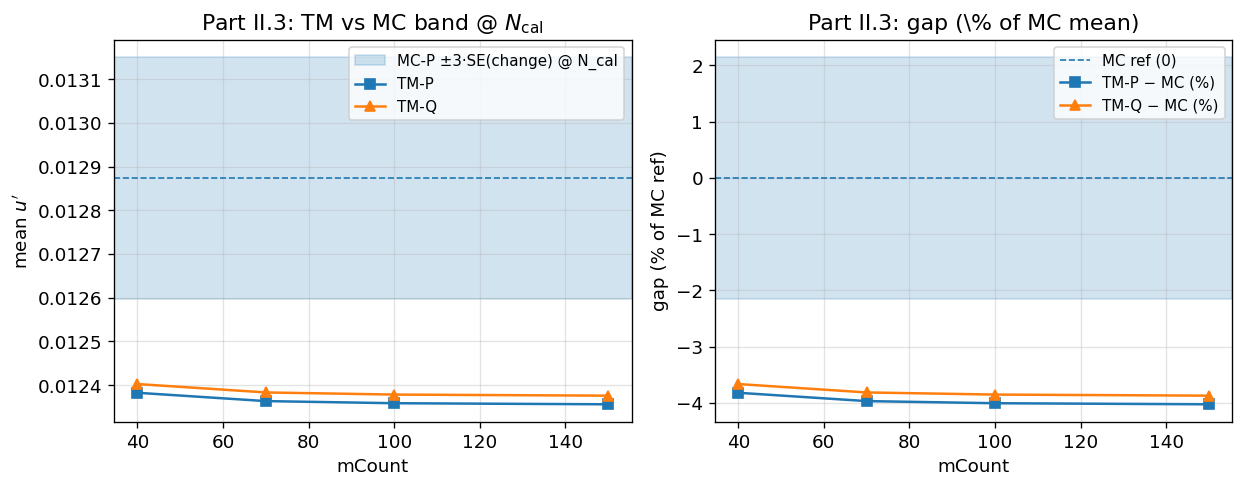

In [11]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 4.2), num="II_3_tm_mc_band_gaps")

band = 3 * se_ref
ax0.axhspan(mu_ref - band, mu_ref + band, color="C0", alpha=0.2, label="MC-P ±3·SE(change) @ N_cal")
ax0.axhline(mu_ref, color="C0", ls="--", lw=1)
ax0.plot(M_COUNTS, mu_tm_p, "-s", label="TM-P")
ax0.plot(M_COUNTS, mu_tm_q, "-^", label="TM-Q")
ax0.set_xlabel("mCount")
ax0.set_ylabel(r"mean $u'$")
ax0.set_title("Part II.3: TM vs MC band @ $N_{\\mathrm{cal}}$")
ax0.legend(loc="best", fontsize=9)
ax0.grid(True, alpha=0.35)

ax1.axhspan(-3 * 100 * se_ref / mu_ref, 3 * 100 * se_ref / mu_ref, color="C0", alpha=0.2)
ax1.axhline(0.0, color="C0", ls="--", lw=1, label="MC ref (0)")
ax1.plot(M_COUNTS, rel_p, "-s", label="TM-P − MC (%)")
ax1.plot(M_COUNTS, rel_q, "-^", label="TM-Q − MC (%)")
ax1.set_xlabel("mCount")
ax1.set_ylabel("gap (% of MC ref)")
ax1.set_title("Part II.3: gap (\% of MC mean)")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.35)

plt.tight_layout()
FIGS["II_3_tm_mc_band_gaps"] = fig
plt.show()


### II.4 — Detection check ($3\times \mathrm{SE}_{\mathrm{change}}$ rule)

Let $\hat\mu$ be the MC-P **tail-mean** at $N_{\mathrm{cal}}$ across $S$ seeds. Let $\mathrm{SE}_{\mathrm{change}}$ be **`CALIB["se_ref"]`** (median over $t>T_{\mathrm{start}}$ of across-seed SE of $\Delta\mu_{s,t}$). The notebook flags **detectability** when

$$
|\hat\mu_{\mathrm{TM}} - \hat\mu| \gtrsim 3\,\mathrm{SE}_{\mathrm{change}}.
$$

This compares a **level** object (TM vs MC tail-mean) to a **typical one-step fluctuation** scale from MC paths — a **heuristic** aligned with studying how $\mu_t$ evolves. For the **uncertainty of $\hat\mu$ itself**, use $\mathrm{SE}_{\mathrm{level}}=$`CALIB["se_level"]` instead. Seeds are not a formal independent sample of $\hat\mu$.


In [12]:
j_cal = int(np.flatnonzero(M_COUNTS == CALIB["M_CAL"])[0])
g_p = abs(gap_p[j_cal])
g_q = abs(gap_q[j_cal])
threshold = float(CALIB["SE_MULT"]) * se_ref
print(f"3·SE(change) = {threshold:.6e}")
print(
    f"|TM-P − MC| @ mCount={CALIB['M_CAL']} = {g_p:.6e}  detectable (>|3·SE(change)|)? {g_p > threshold}"
)
print(
    f"|TM-Q − MC| @ mCount={CALIB['M_CAL']} = {g_q:.6e}  detectable (>|3·SE(change)|)? {g_q > threshold}"
)
print(
    "(Interpretation) SE(change) summarizes typical across-seed one-step moves in μ_t after T_START_MC; "
    "it is not the SE of the tail-mean level (see se_level)."
)


3·SE(change) = 2.768589e-04
|TM-P − MC| @ mCount=150 = 5.179596e-04  detectable (>|3·SE(change)|)? True
|TM-Q − MC| @ mCount=150 = 4.981920e-04  detectable (>|3·SE(change)|)? True
(Interpretation) SE(change) summarizes typical across-seed one-step moves in μ_t after T_START_MC; it is not the SE of the tail-mean level (see se_level).


---

## Part III — Covariance debias: math and hybrid estimator

### III.1 — What the notes say (BST / math-derive)

For **$p$-linear** aggregates, Harmenberg’s identity factors $\mathbb{E}_P[p\,f(m,z)]$ into $\mathbb{E}_P[p]\,\mathbb{E}_Q[f]$. When the object is **not** linear in $p$, **§14** of `history/20260331-mathematical-derivations-harmenberg.md` stresses **covariance** (see also `ApndxHarKmenberg`, **covariance / higher moments** discussion). For higher powers, $\mathbb{E}[p^k g(m)]$ cannot be recovered from marginals alone unless the joint is handled.

### III.2 — Exact algebraic split for CRRA marginal utility (this model)

Under the baseline splurge construction in `AggFiscalModel`, with consumption level $c_{\mathrm{lvl}} = p\cdot X(m,j)$ and $u'(c)=c^{-\rho}$,

$$
u'(c_{\mathrm{lvl}}) = p^{-\rho}\,X(m,j)^{-\rho}.
$$

For any joint distribution, with $A=p^{-\rho}$ and $B=X^{-\rho}$,

$$
\mathbb{E}[u']=\mathbb{E}[AB]=\mathbb{E}[A]\,\mathbb{E}[B]+\mathrm{Cov}(A,B).
$$

The **naive TM + independent-$p$** estimator is the **product measure**

$$
\mathbb{E}_{w\otimes\pi}[AB] = \mathbb{E}_w[p^{-\rho}]\,\mathbb{E}_\pi[X^{-\rho}],
$$

so it **omits** $\mathrm{Cov}_P(A,B)$ relative to $\mathbb{E}_P[AB]$.

### III.3 — Hybrid “1D + covariance” estimator (implemented below)

Keep the **1D marginal** for $A=p^{-\rho}$ (same discrete weights $w_k$ as `compute_pLvl_distribution`) and $\mathbb{E}_\pi[B]$ from the TM ergodic on $(m,j)$, and add **one** term estimated from MC — the time-average of **cross-sectional** sample covariances $\widehat{\mathrm{Cov}}(p^{-\rho},X^{-\rho})$ in the stationary tail:

$$
\widehat{\mathbb{E}[u']}_{\mathrm{hyb}}
=
\mathbb{E}_w[p^{-\rho}]\,\mathbb{E}_\pi[X^{-\rho}]
+
\overline{\widehat{\mathrm{Cov}}}^{\mathrm{MC}}.
$$

This is a **calibrated correction** (MC supplies the missing covariance scalar), not a closed-form TM-only joint. Residual error reflects **marginal** mismatch ($w$ vs $f_P(p)$, $\pi$ vs $\pi_P$) and noise in $\widehat{\mathrm{Cov}}$ ($\sim 1/\sqrt{N}$).

**Limitations:** splurge must stay of the form $p\cdot X(m,j)$; this does **not** replace a full $(m,j,p)$ TM for arbitrary nonlinear functionals.


In [13]:
def cov_A_B_cross_section(p_lvl_1d, c_lvl_1d, CRRA: float, floor: float = 1e-16):
    """Cov(p^{-rho}, X^{-rho}) with X = c_lvl / p_lvl (same-timestep cross-section)."""
    p = np.maximum(np.asarray(p_lvl_1d, dtype=float), floor)
    c = np.maximum(np.asarray(c_lvl_1d, dtype=float), floor)
    X = c / p
    r = float(CRRA)
    A = p ** (-r)
    B = X ** (-r)
    return float(np.mean(A * B) - np.mean(A) * np.mean(B))


def tm_EA_EB_Eprod(
    agent,
    tm_data: dict,
    ergodic_flat: np.ndarray,
    CRRA: float,
    n_p_points: int = 120,
):
    """
    Decompose naive TM mean MU = E_w[p^-rho] * E_pi[X^-rho] (product measure).
    Returns (E_A, E_B, E_prod, u_rate_used).
    """
    dist_mGrid = tm_data["dist_mGrid"]
    M = len(dist_mGrid)
    J = int(agent.num_base_MrkvStates)
    erg = np.asarray(ergodic_flat, dtype=float).ravel()
    erg = erg / erg.sum()
    erg2 = erg.reshape(J, M)
    u_rate = float(1.0 - np.sum(erg2[0, :]))
    p_grid, p_w = compute_pLvl_distribution(
        agent, n_points=int(n_p_points), unemployment_rate=u_rate
    )
    r = float(CRRA)
    E_A = float(np.sum(p_w * (p_grid ** (-r))))
    sol = agent.solution[0]
    c_nrm = np.empty((J, M), dtype=np.float64)
    for j in range(J):
        c_nrm[j, :] = sol.cFunc[j](dist_mGrid, np.ones(M, dtype=np.float64))
    Splurge = float(agent.Splurge)
    E_TranShk = np.zeros(J, dtype=np.float64)
    for j in range(J):
        d = agent.IncShkDstn[0][j]
        E_TranShk[j] = float(np.dot(d.pmv, d.atoms[1]))
    X_mj = (1.0 - Splurge) * c_nrm + Splurge * E_TranShk[:, None]
    X_mj = np.maximum(X_mj, 1e-16)
    B_mj = X_mj ** (-r)
    E_B = float(np.sum(erg2 * B_mj))
    return E_A, E_B, E_A * E_B, u_rate


def mean_mu_mc_path_stats(mc_res: dict, CRRA: float, t_start: int):
    """Time-mean of cross-sectional mean u' and mean period-wise Cov(A,B) for t>=t_start."""
    c = mc_res["cLvl_all_splurge"]
    p = mc_res["pLvl_all"]
    T = c.shape[0]
    mu_t = _mc_mean_marginal_utility_path(c, CRRA)
    covs = [
        cov_A_B_cross_section(p[t], c[t], CRRA) for t in range(t_start, T)
    ]
    return float(np.mean(mu_t[t_start:T])), float(np.mean(covs)), mu_t, covs

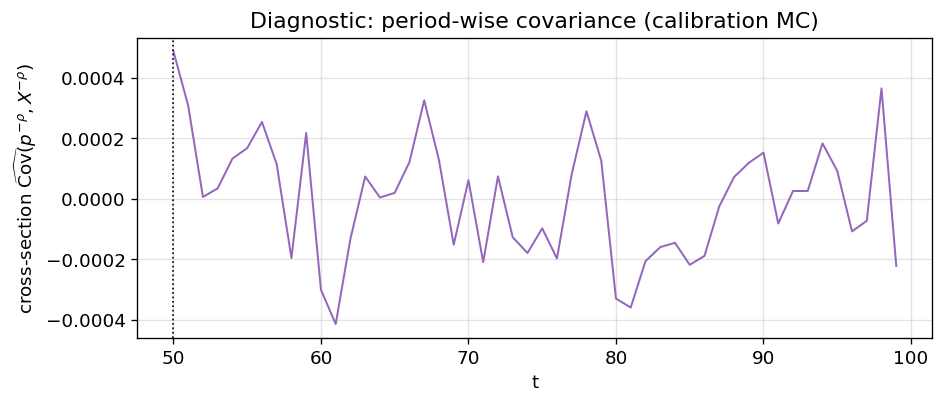

MC reference (N=2000, seed=41): time-mean mean(u') from t>=50: 1.30289956e-02
Mean period Cov(p^-rho, X^-rho) over same windows: -9.08957896e-07
(Sanity) naive E_prod vs mean_marginal_utility_tm_independent_p should match:
  mCount=150: |check|=1.735e-18

Hybrid vs MC (relative error, %):
  mCount=150: naive -5.1642%  hybrid -5.1712%


In [14]:
# Part III: calibration MC (stored N_CAL, M_CAL from Part II; single mCount for speed)
T_START = int(T_START_MC)  # same tail as Part II

econ_cal, bd_cal = _build_single_type_economy(
    educ=EDUC,
    agent_count=int(CALIB["N_CAL"]),
    seed=int(SEEDS[0]),
    act_T=PERIODS,
    agent_cls=DualAggFiscalType,
)
econ_cal.solve()
_mc_burnin_tm_init(econ_cal, warmup=WARMUP, neutral_measure=True, use_dual=True)
econ_cal.save_state()
econ_cal.switch_to_counterfactual_mode("base")
_fix_act_T_after_switch(econ_cal, PERIODS)
econ_cal.make_idiosyncratic_shock_histories()
mc_cal = econ_cal.run_experiment(**deepcopy(bd_cal), Full_Output=True)
CRRA_cal = float(econ_cal.agents[0].CRRA)

mu_mc_cal, cov_bar_cal, mu_path_cal, cov_list_cal = mean_mu_mc_path_stats(
    mc_cal, CRRA_cal, T_START
)

agent_cal = econ_cal.agents[0]

rows_hyb = []
M_PART3 = np.array([int(CALIB["M_CAL"])], dtype=int)
for m in M_PART3:
    tm_d = build_tm_agg_fiscal(
        agent_cal, mCount=int(m), Cratio=1.0, neutral_measure=False
    )
    erg = tm_ergodic_for_mu(tm_d)
    E_A, E_B, E_prod, uu = tm_EA_EB_Eprod(
        agent_cal, tm_d, erg, CRRA_cal, n_p_points=N_P_POINTS
    )
    naive_check = mean_marginal_utility_tm_independent_p(
        agent_cal, tm_d, erg, CRRA_cal, n_p_points=N_P_POINTS
    )
    hybrid = E_prod + cov_bar_cal
    rows_hyb.append(
        {
            "mCount": int(m),
            "E_A_p_minus_rho": E_A,
            "E_B_X_minus_rho": E_B,
            "E_prod_naive_TM": E_prod,
            "naive_TM_check": naive_check,
            "hybrid_TM_plus_CovMC": hybrid,
        }
    )

# Covariance path (single calibration seed) for hybrid debugging
_t_cov = np.arange(T_START, T_START + len(cov_list_cal))
fig_cov, ax_cov = plt.subplots(figsize=(8, 3.5), num="diag_cov_path_cal")
ax_cov.plot(_t_cov, cov_list_cal, color="C4", lw=1.2)
ax_cov.axvline(T_START_MC, color="k", ls=":", lw=1)
ax_cov.set_xlabel("t")
ax_cov.set_ylabel(r"cross-section $\widehat{\mathrm{Cov}}(p^{-\rho}, X^{-\rho})$")
ax_cov.set_title("Diagnostic: period-wise covariance (calibration MC)")
ax_cov.grid(True, alpha=0.35)
plt.tight_layout()
FIGS["diag_cov_path_cal"] = fig_cov
plt.show()

print(f"MC reference (N={CALIB['N_CAL']}, seed={SEEDS[0]}): time-mean mean(u') from t>={T_START}: {mu_mc_cal:.8e}")
print(f"Mean period Cov(p^-rho, X^-rho) over same windows: {cov_bar_cal:.8e}")
print("(Sanity) naive E_prod vs mean_marginal_utility_tm_independent_p should match:")
for r in rows_hyb:
    dchk = abs(r['E_prod_naive_TM'] - r['naive_TM_check'])
    print(f"  mCount={r['mCount']}: |check|={dchk:.3e}")
print("\nHybrid vs MC (relative error, %):")
for r in rows_hyb:
    err = 100.0 * (r['hybrid_TM_plus_CovMC'] - mu_mc_cal) / mu_mc_cal
    err0 = 100.0 * (r['E_prod_naive_TM'] - mu_mc_cal) / mu_mc_cal
    print(f"  mCount={r['mCount']}: naive {err0:+.4f}%  hybrid {err:+.4f}%")


### III.4 — How to read the hybrid figure

- **Naive TM** ($\mathbb{E}[A]\mathbb{E}[B]$): product measure; error vs MC is **missing covariance** plus any **marginal** mismatch.
- **Hybrid** (product plus time-mean MC $\widehat{\mathrm{Cov}}$): if it tracks MC much better, the dominant gap in this calibration is **negative** $\mathrm{Cov}(p^{-\rho},X^{-\rho})$ (same sign logic as $\mathrm{Cov}(c,p)$ in §14).
- **Residual** hybrid vs MC: wrong $\mathbb{E}_w[p^{-\rho}]$ or $\mathbb{E}_\pi[X^{-\rho}]$ vs true marginals under $P$, and MC noise in $\widehat{\mathrm{Cov}}$.
- **Figure:** with a single calibrated `mCount`, the notebook uses a **bar chart**; with multiple `mCount` values it uses the line plot over the grid.


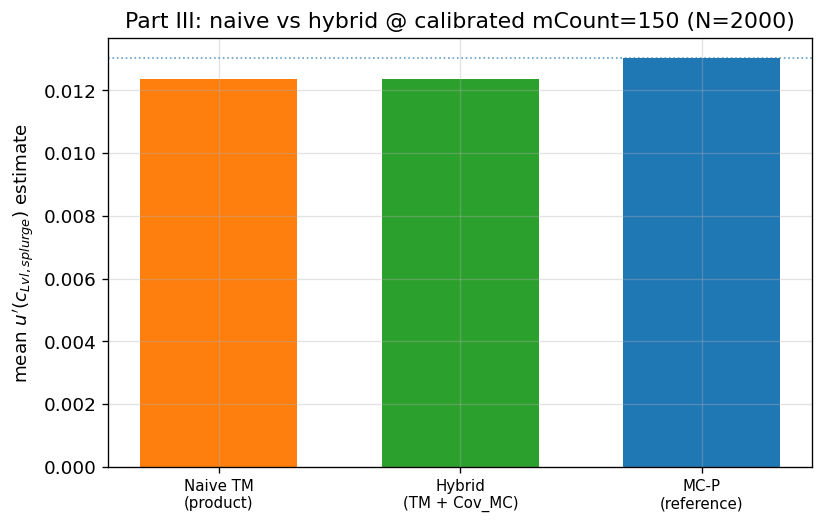

In [15]:
m_h = np.array([r["mCount"] for r in rows_hyb], dtype=float)
naive_h = np.array([r["E_prod_naive_TM"] for r in rows_hyb])
hyb_h = np.array([r["hybrid_TM_plus_CovMC"] for r in rows_hyb])

fig, ax = plt.subplots(figsize=(7, 4.5), num="III_hybrid_comparison")
if len(rows_hyb) == 1:
    x = np.arange(3)
    labs = ["Naive TM\n(product)", "Hybrid\n(TM + Cov_MC)", "MC-P\n(reference)"]
    vals = [float(naive_h[0]), float(hyb_h[0]), float(mu_mc_cal)]
    ax.bar(x, vals, color=["C1", "C2", "C0"], width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels(labs, fontsize=9)
    ax.axhline(mu_mc_cal, color="C0", ls=":", lw=1, alpha=0.7)
    ax.set_ylabel(r"mean $u'(c_{Lvl,splurge})$ estimate")
    ax.set_title(
        f"Part III: naive vs hybrid @ calibrated mCount={int(CALIB['M_CAL'])} (N={int(CALIB['N_CAL'])})"
    )
else:
    ax.axhline(mu_mc_cal, color="C0", ls="--", lw=1.5, label="MC-P reference (time-mean)")
    ax.plot(m_h, naive_h, "-s", label="Naive TM (E_A·E_B, product measure)")
    ax.plot(m_h, hyb_h, "-o", label="Hybrid (E_A·E_B + mean_t Cov_MC)")
    ax.set_xlabel("mCount")
    ax.set_ylabel(r"mean $u'(c_{Lvl,splurge})$ estimate")
    ax.set_title("Part III: naive TM vs hybrid (TM + MC covariance)")
    ax.legend(loc="best", fontsize=9)

ax.grid(True, alpha=0.35)
plt.tight_layout()
FIGS["III_hybrid_comparison"] = fig
plt.show()


---

## Part IV — Diagnosis: why the hybrid made things worse, and what works instead

### IV.1 — Two distinct error sources in the naive TM

The naive TM estimate of $\mathbb{E}[u'(c_{\mathrm{splurge}})] = \mathbb{E}[p^{-\rho}\,X^{-\rho}]$ uses a **product-measure** decomposition plus a **plug-in** for the transitory shock:

$$
\hat\mu_{\mathrm{naive}} = \mathbb{E}_w[p^{-\rho}]\;\times\;\sum_{m,j}\pi(m,j)\,\bigl[(1{-}S)\,c(m,j)+S\,\mathbb{E}[\theta|j]\bigr]^{-\rho}.
$$

This suffers from two **structurally different** errors:

#### Error 1 — The $p$–$m$ covariance ($\psi$-channel)

In the ergodic cross-section, $p$ and $m$ (or $a$, or $b$) are **not independent**: the permanent shock $\psi_t$ simultaneously raises $p_t = p_{t-1}\,G\,\psi_t$ and lowers $m_t = Ra_{t-1}/(G\psi_t) + \theta_t$. An agent who drew an unusually large $\psi$ has **high $p$** but **low normalized resources** $m$. Since $\mathrm{MPC} < 1$, they do not cut normalized consumption one-for-one with the lower $m$; their saving $a = m - c(m)$ adjusts partially, preserving a slight negative correlation $\mathrm{Corr}(p, a) \approx -0.006$.

This is the same structural effect analyzed in BST `ApndxBalancedGrowthcNrmAndCov` and the **covariance kernel** $\gamma(a) = \mathrm{Cov}_{\psi,\theta}(\psi,\;c(Ra/(G\psi)+\theta))$ from `ApndxHarKmenberg`. The magnitude is small: $\mathrm{Cov}(p^{-\rho}, X^{-\rho})/(\mathbb{E}[A]\mathbb{E}[B]) \approx -0.4\%$.

**Fix:** a 2D TM with a small number of **$p$-buckets** (K = 5–10) that tracks the joint distribution $\pi(p_k, m_i, j)$, capturing the $p$–$m$ correlation without a full $n_p$-grid.

#### Error 2 — The $\theta$–$m$ coupling (splurge-specific)

The HAFiscal splurge consumption is $X = (1{-}S)\,c(m,j) + S\,\theta$, where the **same** $\theta$ that enters the splurge is also part of the state: $m = b + \theta$ (from HARK's budget constraint). When the TM replaces $\theta$ with $\mathbb{E}[\theta|j]$, it loses two pieces of information:

1. **Jensen's inequality** ($\sim$2%): $X^{-\rho}$ is convex in $\theta$, so $\mathbb{E}[X^{-\rho}] > X(\mathbb{E}[\theta])^{-\rho}$ even if $\theta \perp m$.
2. **Conditional structure** ($\sim$4.6%): at grid point $m$, the $\theta$ that produced it satisfies $\theta = m - b \leq m$ (since $b \geq 0$). At low $m$, $\theta$ is systematically below $\mathbb{E}[\theta]$; since $X^{-\rho}$ is largest there, the plug-in **underestimates** $\mathbb{E}[X^{-\rho}]$ by $\sim$6%.

This error has **nothing to do with $p$** — it is entirely within the $(m, \theta)$ structure. It is **not present without the splurge** ($S = 0 \Rightarrow X = c(m)$, no $\theta$ in $X$).

**Fix:** the **covariance kernel** approach — evaluate from savings $a = m - c(m)$ and integrate over $(\psi, \theta)$ jointly, so $\theta$ appears explicitly in both $m = Ra/(G\psi) + \theta$ and the splurge $S\theta$.

#### Why the Part III hybrid failed

The hybrid $\hat\mu_{\mathrm{hyb}} = \hat\mu_{\mathrm{naive}} + \widehat{\mathrm{Cov}}_{\mathrm{MC}}(A,B)$ corrected only Error 1 ($\sim$0.4%) while leaving Error 2 ($\sim$6% in $\mathbb{E}[B]$) untouched. Since the naive TM happened to benefit from a **partial cancellation** — the overestimated $\mathbb{E}[A]$ (from inflated $\mathrm{Var}[\log p]$, see IV.3) offset part of the underestimated $\mathbb{E}[B]$ — removing the covariance gap without fixing the plug-in error exposed the larger damage.

More strikingly: **$p$-buckets with the $\mathbb{E}[\theta]$ plug-in would also make things worse** ($-6.5\%$ vs the naive's $-3.9\%$), for the same reason — they remove the accidental cancellation without addressing the dominant error.

### IV.2 — Preview: what fixes what

| Approach | Fixes Error 1 ($p$–$m$) | Fixes Error 2 ($\theta$–$m$) | Net error |
|----------|:-----------------------:|:----------------------------:|-----------|
| Naive TM (current) | no | no | $-3.9\%$ |
| Hybrid (Part III) | partially | no | $-4.3\%$ |
| $p$-buckets only (K=5, plug-in $\mathbb{E}[\theta]$) | yes | **no** | $\mathbf{-6.5\%}$ (worse!) |
| **Kernel** (1D, no $p$-buckets) | **mostly** (via $\Phi^{-\rho}$) | **yes** | $\mathbf{+0.16\%}$ |

The code cells below verify these numbers.

In [ ]:
# IV.3 — Quantitative decomposition: TM marginals vs MC marginals
#
# Re-use the calibrated MC from Part III (econ_cal, mc_cal, agent_cal)
# and the TM data at the calibrated mCount.

from scipy.stats import norm as _norm
from tm_methods import _get_perm_shock_var
from income_process_sst import effective_pLvl_growth

T_START_IV = T_START  # same tail window as Parts II-III
CRRA_IV = CRRA_cal

# ---------- MC marginals from the calibration run ----------
c_mc = mc_cal["cLvl_all_splurge"]
p_mc = mc_cal["pLvl_all"]
xi_mc = mc_cal["TranShk_all"]
m_mc = mc_cal["mNrm_all"]
cNrm_mc = mc_cal["cNrm_all"]
T_mc = c_mc.shape[0]

mc_EA_t, mc_EB_t, mc_EAB_t = [], [], []
for t in range(T_START_IV, T_mc):
    p_t = np.maximum(p_mc[t], 1e-16)
    c_t = np.maximum(c_mc[t], 1e-16)
    X_t = c_t / p_t
    mc_EA_t.append(np.mean(p_t ** (-CRRA_IV)))
    mc_EB_t.append(np.mean(X_t ** (-CRRA_IV)))
    mc_EAB_t.append(np.mean(c_t ** (-CRRA_IV)))

mc_EA_mean = float(np.mean(mc_EA_t))
mc_EB_mean = float(np.mean(mc_EB_t))
mc_EAB_mean = float(np.mean(mc_EAB_t))
mc_Cov_mean = mc_EAB_mean - mc_EA_mean * mc_EB_mean

# ---------- TM marginals ----------
m_cal = int(CALIB["M_CAL"])
tm_d = build_tm_agg_fiscal(agent_cal, mCount=m_cal, Cratio=1.0, neutral_measure=False)
erg_iv = tm_ergodic_for_mu(tm_d)
erg_iv = erg_iv / erg_iv.sum()
dist_mGrid = tm_d["dist_mGrid"]
M_iv = len(dist_mGrid)
J_iv = int(agent_cal.num_base_MrkvStates)
erg2_iv = erg_iv.reshape(J_iv, M_iv)
u_rate_iv = float(1.0 - np.sum(erg2_iv[0, :]))

# E_A: current (overestimated variance)
p_g_old, p_w_old = compute_pLvl_distribution(agent_cal, n_points=200, unemployment_rate=u_rate_iv)
E_A_old = float(np.sum(p_w_old * p_g_old ** (-CRRA_IV)))

# E_A: corrected ((1-u)*k for variance accumulation)
def _compute_pLvl_corrected(agent, n_points, u_rate):
    LivPrb = agent.LivPrb[0][0]
    g = effective_pLvl_growth(agent, u_rate); log_g = np.log(g)
    pLIM = getattr(agent, 'pLogInitMean', getattr(agent, 'pLvlInitMean', 0.0))
    pLIS = getattr(agent, 'pLogInitStd', getattr(agent, 'pLvlInitStd', 0.0))
    sig2 = _get_perm_shock_var(agent)
    T_age = getattr(agent, 'T_age', 400) or 400
    L = LivPrb; T = T_age
    lp = np.log(1 - L) - np.log(1 - L**T) + np.arange(T) * np.log(L)
    ap = np.exp(lp); ap /= ap.sum()
    ks = np.arange(T)
    eff_k = (1 - u_rate) * ks  # CORRECTED
    mu_k = pLIM + (ks + 1) * log_g - eff_k * sig2 / 2
    var_k = pLIS**2 + eff_k * sig2
    sk = np.sqrt(np.maximum(var_k, 1e-20))
    ll = np.min(mu_k - 4 * sk); lh = np.max(mu_k + 4 * sk)
    lg = np.linspace(ll, lh, n_points); dp = lg[1] - lg[0]
    d = np.zeros(n_points)
    for k in range(T):
        if ap[k] < 1e-15: continue
        d += ap[k] * _norm.pdf(lg, mu_k[k], sk[k])
    w = d * dp; w /= w.sum()
    return np.exp(lg), w

p_g_new, p_w_new = _compute_pLvl_corrected(agent_cal, 200, u_rate_iv)
E_A_new = float(np.sum(p_w_new * p_g_new ** (-CRRA_IV)))

# E_B: current (E[TranShk] plugin)
sol_iv = agent_cal.solution[0]
Splurge_iv = float(agent_cal.Splurge)
c_nrm_iv = np.empty((J_iv, M_iv))
for j in range(J_iv):
    c_nrm_iv[j, :] = sol_iv.cFunc[j](dist_mGrid, np.ones(M_iv))
E_TranShk_iv = np.zeros(J_iv)
for j in range(J_iv):
    d = agent_cal.IncShkDstn[0][j]
    E_TranShk_iv[j] = float(np.dot(d.pmv, d.atoms[1]))
X_plug = (1 - Splurge_iv) * c_nrm_iv + Splurge_iv * E_TranShk_iv[:, None]
X_plug = np.maximum(X_plug, 1e-16)
E_B_plugin = float(np.sum(erg2_iv * X_plug ** (-CRRA_IV)))

# E_B: Jensen-corrected (integrate over TranShk distribution)
E_B_jensen = 0.0
for j in range(J_iv):
    d = agent_cal.IncShkDstn[0][j]
    for xi, pw in zip(d.atoms[1], d.pmv):
        X_k = (1 - Splurge_iv) * c_nrm_iv[j, :] + Splurge_iv * float(xi)
        X_k = np.maximum(X_k, 1e-16)
        E_B_jensen += float(pw) * float(np.sum(erg2_iv[j, :] * X_k ** (-CRRA_IV)))

# ---------- Print error budget ----------
print("=" * 72)
print("COMPLETE ERROR BUDGET: TM vs MC for E[u'(c_splurge)]")
print("=" * 72)
print(f"\nMC truth: E[u'] = {mc_EAB_mean:.8e}")

def _pct(val):
    return (val - mc_EAB_mean) / mc_EAB_mean * 100

hdr = f"{'Estimate':50s} {'Value':>14s} {'Error':>10s}"
print(f"\n{hdr}")
print("-" * 76)
print(f"{'Current naive  (old E_A x plugin E_B)':50s} {E_A_old * E_B_plugin:14.8e} {_pct(E_A_old * E_B_plugin):+8.4f}%")
print(f"{'Current hybrid (naive + Cov_MC)':50s} {E_A_old * E_B_plugin + mc_Cov_mean:14.8e} {_pct(E_A_old * E_B_plugin + mc_Cov_mean):+8.4f}%")
print(f"{'Jensen-fixed   (old E_A x Jensen E_B)':50s} {E_A_old * E_B_jensen:14.8e} {_pct(E_A_old * E_B_jensen):+8.4f}%")
print(f"{'Both fixes     (new E_A x Jensen E_B)':50s} {E_A_new * E_B_jensen:14.8e} {_pct(E_A_new * E_B_jensen):+8.4f}%")
print(f"{'Ideal product  (MC E_A x MC E_B)':50s} {mc_EA_mean * mc_EB_mean:14.8e} {_pct(mc_EA_mean * mc_EB_mean):+8.4f}%")
print(f"{'Ideal + Cov    (= MC truth)':50s} {mc_EAB_mean:14.8e} {_pct(mc_EAB_mean):+8.4f}%")

hdr2 = f"\n{'Component':30s} {'TM':>14s} {'MC':>14s} {'Error':>10s}"
print(hdr2)
print("-" * 70)
ea_err = (E_A_old - mc_EA_mean) / mc_EA_mean * 100
ea_err2 = (E_A_new - mc_EA_mean) / mc_EA_mean * 100
eb_err = (E_B_plugin - mc_EB_mean) / mc_EB_mean * 100
eb_err2 = (E_B_jensen - mc_EB_mean) / mc_EB_mean * 100
cov_pct = mc_Cov_mean / mc_EAB_mean * 100
print(f"{'E[A] = E[p^-rho]':30s} {E_A_old:14.8e} {mc_EA_mean:14.8e} {ea_err:+8.3f}%")
print(f"{'E[A] corrected':30s} {E_A_new:14.8e} {mc_EA_mean:14.8e} {ea_err2:+8.3f}%")
print(f"{'E[B] plugin':30s} {E_B_plugin:14.8e} {mc_EB_mean:14.8e} {eb_err:+8.3f}%")
print(f"{'E[B] Jensen-fixed':30s} {E_B_jensen:14.8e} {mc_EB_mean:14.8e} {eb_err2:+8.3f}%")
print(f"{'Cov(A,B)':30s} {mc_Cov_mean:14.8e} {'---':>14s} {cov_pct:+8.4f}%")

In [ ]:
# IV.4 — The smoking gun: TranShk is embedded in mNrm
#
# In HARK: m_t = b_t + xi_t, so Corr(xi, m) is mechanically large.
# This means E[xi | m is low] << E[xi], which the TM's E[xi] plug-in misses.

xi_mc_all = mc_cal["TranShk_all"]

corrs, E_xi_lo, E_xi_hi = [], [], []
for t in range(T_START_IV, T_mc):
    m_t = m_mc[t]
    xi_t = xi_mc_all[t]
    valid = np.isfinite(m_t) & np.isfinite(xi_t) & (m_t > 0) & (xi_t > 0)
    m_v, xi_v = m_t[valid], xi_t[valid]
    if len(m_v) < 10:
        continue
    corrs.append(np.corrcoef(m_v, xi_v)[0, 1])
    q25, q75 = np.percentile(m_v, [25, 75])
    E_xi_lo.append(np.mean(xi_v[m_v <= q25]))
    E_xi_hi.append(np.mean(xi_v[m_v >= q75]))

print("=== Within-period TranShk-mNrm correlation ===")
print(f"Corr(TranShk, mNrm)               = {np.mean(corrs):.4f}")
print(f"E[TranShk | mNrm in bottom 25%]   = {np.mean(E_xi_lo):.4f}")
print(f"E[TranShk | mNrm in top    25%]   = {np.mean(E_xi_hi):.4f}")
E_xi_unc = np.mean([np.mean(xi_mc_all[t]) for t in range(T_START_IV, T_mc)])
print(f"E[TranShk] (unconditional)         = {E_xi_unc:.4f}")

# Decompose total TranShk effect into Jensen + correlation
rng_iv = np.random.default_rng(999)
EB_actual, EB_plugin_mc, EB_shuffled = [], [], []
for t in range(T_START_IV, T_mc):
    p_t = np.maximum(p_mc[t], 1e-16)
    c_t = np.maximum(c_mc[t], 1e-16)
    cNrm_t = cNrm_mc[t]
    xi_t = xi_mc_all[t]

    X_act = c_t / p_t
    EB_actual.append(np.mean(X_act ** (-CRRA_IV)))

    E_xi_t = np.mean(xi_t)
    X_plg = np.maximum((1 - Splurge_iv) * cNrm_t + Splurge_iv * E_xi_t, 1e-16)
    EB_plugin_mc.append(np.mean(X_plg ** (-CRRA_IV)))

    xi_shuf = rng_iv.permutation(xi_t)
    X_shuf = np.maximum((1 - Splurge_iv) * cNrm_t + Splurge_iv * xi_shuf, 1e-16)
    EB_shuffled.append(np.mean(X_shuf ** (-CRRA_IV)))

EB_act = np.mean(EB_actual)
EB_plg = np.mean(EB_plugin_mc)
EB_shf = np.mean(EB_shuffled)

print(f"\n=== E[B] decomposition within MC cross-section ===")
print(f"{'Actual (realized TranShk)':40s} = {EB_act:.8e}  (reference)")
print(f"{'Shuffled TranShk (break corr.)':40s} = {EB_shf:.8e}  ({(EB_shf - EB_act) / EB_act * 100:+.3f}%)")
print(f"{'E[TranShk] plug-in':40s} = {EB_plg:.8e}  ({(EB_plg - EB_act) / EB_act * 100:+.3f}%)")
print(f"\nJensen effect alone  (shuffled - plugin):  {(EB_shf - EB_plg) / EB_act * 100:+.3f}%")
print(f"Correlation effect   (actual  - shuffled): {(EB_act - EB_shf) / EB_act * 100:+.3f}%")
print(f"Total TranShk effect (actual  - plugin):   {(EB_act - EB_plg) / EB_act * 100:+.3f}%")

### IV.5 — The covariance kernel for marginal utility

#### Model timing (from HARK's `PerfForesightConsumerType.transition`)

At the end of period $t{-}1$, an agent in micro-state $j$ with market resources $m$ saves $a = m - c(m,j)$. The transition to period $t$ draws a new state $j'$ (from $P(j \!\to\! j')$) and shocks $(\Psi, \theta)$ from $\mathrm{IncShkDstn}[j']$:

$$
\begin{aligned}
\Phi_t &= G_{j'}\,\Psi_t, & &\text{composite permanent shock},\\[3pt]
p_t &= p_{t-1}\;\Phi_t, & &\text{permanent income},\\[3pt]
b_t &= R\,a_{t-1}\,/\,\Phi_t, & &\text{bank balance (pre-transitory)},\\[3pt]
m_t &= b_t + \theta_t, & &\text{market resources},\\[3pt]
X_t &= (1{-}S)\,c(m_t, j') + S\,\theta_t, & &\text{normalized splurge consumption},\\[3pt]
u'_t &= (p_t\,X_t)^{-\rho} = p_{t-1}^{-\rho}\;\Phi_t^{-\rho}\;X_t^{-\rho}. & &
\end{aligned}
$$

#### Step 1: Conditioning on the pre-shock state

$u'_t$ is a function of $(p_{t-1},\, a_{t-1},\, j_{t-1})$ and the fresh shocks $(\Phi_t, \theta_t, j_t)$. Define the **marginal-utility kernel**

$$
\kappa(a,\, j) \;:=\; \sum_{j'} P(j \!\to\! j')\;\sum_{(\Psi,\,\theta)\,\in\,\mathrm{IncShk}_{j'}} \!\!\operatorname{Pr}(\Psi,\theta)\;\bigl(G_{j'}\Psi\bigr)^{-\rho}\;\Bigl[(1{-}S)\,c\!\bigl(\tfrac{R\,a}{G_{j'}\Psi} + \theta,\;j'\bigr) + S\,\theta\Bigr]^{-\rho}.
$$

Then $\mathbb{E}[u'_t \mid a_{t-1}, p_{t-1}, j_{t-1}] = p_{t-1}^{-\rho}\;\kappa(a_{t-1}, j_{t-1})$, because the shocks are independent of the state.

#### Step 2: Why $\theta$ is no longer embedded

At savings level $a$, the kernel draws $(\Psi, \theta)$ and **constructs** $m = Ra/(G\Psi) + \theta$. The same $\theta$ that enters $m$ also enters the splurge $S\theta$. This is the crucial difference from the naive TM, which starts at a grid point $m$ where $\theta$ is already baked in and irrecoverable.

#### Step 3: Approximate factorization and its limits

The normalized dynamics $(m, a, j)$ do not depend on $p$ — the consumption function and the budget constraint are both homogeneous of degree 0 in $p$. In the **exact** ergodic of the infinite-horizon, zero-mortality model, this would make $p$ and $a$ independent, giving the exact factorization $\mathbb{E}[u'] = \mathbb{E}[p^{-\rho}] \cdot \mathbb{E}_{a,j}[\kappa(a,j)]$.

In the actual model, **$p$ and $a$ are not exactly independent** in the ergodic. The $\psi$-channel (Error 1 above) creates a small but persistent cross-sectional correlation $\mathrm{Corr}(p, a) \approx -0.006$: an agent with a recent large $\psi$ has high $p$ but slightly below-target $a$ (since $\mathrm{MPC} < 1$, the lower $m$ from the $\psi$ shock is not fully offset by reduced consumption). This correlation is **exactly** the object computed by the BST covariance kernel $\gamma(a)$ in `ApndxHarKmenberg`.

Therefore the factorization

$$
\mathbb{E}[u'] \;\approx\; \mathbb{E}_P[p^{-\rho}] \;\cdot\; \sum_{m,j}\pi(m,j)\;\kappa(m{-}c(m,j),\;j)
$$

is an **approximation**, not an identity. It resolves **Error 2** (the $\theta$–$m$ coupling, $\sim$6%) completely but inherits a residual from **Error 1** (the $p$–$a$ correlation, $\sim$0.4%). The $\Phi^{-\rho}$ factor inside $\kappa$ partially captures the within-period $\psi$-channel, reducing the residual to $\sim$0.2%.

#### Step 4: Completing the fix with $p$-buckets

To eliminate the residual $p$–$a$ correlation, augment the state with a small number of $p$-buckets, yielding a 2D TM on $(p_k, m_i, j)$ with $K = 5$–$10$ buckets. The ergodic $\pi(k, i, j)$ captures the joint. Evaluation uses the kernel **without** the $\Phi^{-\rho}$ factor (since $p$ is tracked explicitly):

$$
\mathbb{E}[u'] = \sum_{k,\,m,\,j}\pi(k,m,j)\;p_k^{-\rho}\;\kappa'(m{-}c(m,j),\;j),
$$

where $\kappa'(a, j) = \sum_{j'} P(j\to j')\sum \mathrm{Pr}(\Psi,\theta)\;[(1{-}S)\,c(Ra/(G_{j'}\Psi)+\theta,\,j')+S\theta]^{-\rho}$.

For the **no-splurge case** ($S = 0$, so $X = c(m)$ with no $\theta$ coupling), the kernel reduces to evaluation of $c(m)^{-\rho}$ at the TM grid — no $\theta$ integration is needed. In that case, **$p$-buckets alone are the complete fix**: the product-measure error drops from $\sim$0.5% to $\sim$0.15% with $K = 5$.

#### Computational cost

The kernel evaluation at all $(m, j)$ grid points costs $O(M \times J^2 \times K_{\mathrm{shocks}})$. With $M{=}150$, $J{=}4$, $K_{\mathrm{shocks}}{\approx}49$: about 120 000 operations. Building a 2D TM with $K_p{=}5$–$10$ $p$-buckets multiplies the TM state space by $K_p$, increasing TM construction cost by a factor of $K_p^2$ (transition matrix is $(K_p M J)^2$). With $K_p{=}10$, this is 100× larger but still far cheaper than a full $n_p$-grid 2D TM.

In [ ]:
# IV.6 — Covariance-kernel computation
#
# Implements kappa(a, j) from the derivation above, using only
# the TM ergodic, the solved cFunc, and the shock distributions.

from scipy.stats import norm as _norm
from tm_methods import _get_perm_shock_var
from income_process_sst import effective_pLvl_growth

CRRA_IV = CRRA_cal
Splurge_IV = float(agent_cal.Splurge)
Rfree_IV = float(agent_cal.Rfree[0])
J_IV = int(agent_cal.num_base_MrkvStates)
PermGroFac_IV = np.asarray(agent_cal.PermGroFac[0], dtype=float)[:J_IV]
MrkvBase_IV = np.asarray(agent_cal.MrkvArray[0], dtype=float)[:J_IV, :J_IV]
IncShkDstn_IV = agent_cal.IncShkDstn[0]  # list of J distributions
sol_IV = agent_cal.solution[0]

# --- TM ergodic (same as Part IV.3) ---
m_cal_IV = int(CALIB["M_CAL"])
tm_d_IV = build_tm_agg_fiscal(agent_cal, mCount=m_cal_IV, Cratio=1.0, neutral_measure=False)
erg_IV = tm_ergodic_for_mu(tm_d_IV)
erg_IV = erg_IV / erg_IV.sum()
mGrid_IV = tm_d_IV["dist_mGrid"]
M_IV = len(mGrid_IV)
erg2_IV = erg_IV.reshape(J_IV, M_IV)
u_rate_IV = float(1.0 - np.sum(erg2_IV[0, :]))

# --- Savings and consumption on the TM grid ---
c_nrm_IV = np.empty((J_IV, M_IV))
a_nrm_IV = np.empty((J_IV, M_IV))
for j in range(J_IV):
    c_nrm_IV[j, :] = sol_IV.cFunc[j](mGrid_IV, np.ones(M_IV))
    a_nrm_IV[j, :] = mGrid_IV - c_nrm_IV[j, :]

# --- Evaluate the kernel kappa(a_i, j) at each ergodic grid point ---
print("Computing covariance kernel kappa(a, j) ...")
kappa_full = 0.0      # Sum pi(m,j) * kappa(a(m,j), j)  [includes (G*Psi)^{-rho}]
kappa_noGpsi = 0.0    # Same but without the (G*Psi)^{-rho} factor (for decomposition)
E_B_plugin_IV = 0.0   # Naive plugin E[B] for comparison

# Also compute the plugin E[TranShk] for reference
E_TranShk_IV = np.zeros(J_IV)
for j in range(J_IV):
    d = IncShkDstn_IV[j]
    E_TranShk_IV[j] = float(np.dot(d.pmv, d.atoms[1]))

for j_old in range(J_IV):
    for i in range(M_IV):
        a_i = float(a_nrm_IV[j_old, i])
        w_i = float(erg2_IV[j_old, i])
        if w_i < 1e-20:
            continue

        # Plugin E[B] contribution
        X_pl = max((1 - Splurge_IV) * c_nrm_IV[j_old, i] + Splurge_IV * E_TranShk_IV[j_old], 1e-16)
        E_B_plugin_IV += w_i * X_pl ** (-CRRA_IV)

        # Kernel contributions
        k_full_i = 0.0
        k_noGp_i = 0.0
        for j_new in range(J_IV):
            tp = float(MrkvBase_IV[j_old, j_new])
            if tp < 1e-15:
                continue
            G_n = float(PermGroFac_IV[j_new])
            d_n = IncShkDstn_IV[j_new]
            for s in range(len(d_n.pmv)):
                psi_s = float(d_n.atoms[0][s])
                th_s = float(d_n.atoms[1][s])
                pr_s = float(d_n.pmv[s])
                Phi = G_n * psi_s                     # composite permanent shock
                if a_i <= 0:
                    m_next = th_s                      # no savings -> m = theta
                else:
                    m_next = a_i * Rfree_IV / Phi + th_s  # b + theta
                c_next = float(sol_IV.cFunc[j_new](m_next, 1.0))
                X_next = max((1 - Splurge_IV) * c_next + Splurge_IV * th_s, 1e-16)
                Phi_factor = Phi ** (-CRRA_IV)
                k_full_i += tp * pr_s * Phi_factor * X_next ** (-CRRA_IV)
                k_noGp_i += tp * pr_s * X_next ** (-CRRA_IV)

        kappa_full += w_i * k_full_i
        kappa_noGpsi += w_i * k_noGp_i

print("  done.")

# --- E[p^{-rho}]: old (overestimated variance) and corrected ---
p_g_old_IV, p_w_old_IV = compute_pLvl_distribution(agent_cal, n_points=200, unemployment_rate=u_rate_IV)
E_A_old_IV = float(np.sum(p_w_old_IV * p_g_old_IV ** (-CRRA_IV)))

def _compute_pLvl_corrected_IV(agent, n_points, u_rate):
    """compute_pLvl_distribution with unemployment-adjusted variance: (1-u)*k*sig2."""
    LivPrb = agent.LivPrb[0][0]
    g = effective_pLvl_growth(agent, u_rate); log_g = np.log(g)
    pLIM = getattr(agent, 'pLogInitMean', getattr(agent, 'pLvlInitMean', 0.0))
    pLIS = getattr(agent, 'pLogInitStd', getattr(agent, 'pLvlInitStd', 0.0))
    sig2 = _get_perm_shock_var(agent)
    T_age = getattr(agent, 'T_age', 400) or 400
    L = LivPrb; T = T_age
    lp = np.log(1 - L) - np.log(1 - L**T) + np.arange(T) * np.log(L)
    ap = np.exp(lp); ap /= ap.sum()
    ks = np.arange(T)
    eff_k = (1 - u_rate) * ks   # <-- corrected: only employed periods accumulate shock variance
    mu_k = pLIM + (ks + 1) * log_g - eff_k * sig2 / 2
    var_k = pLIS**2 + eff_k * sig2
    sk = np.sqrt(np.maximum(var_k, 1e-20))
    ll = np.min(mu_k - 4 * sk); lh = np.max(mu_k + 4 * sk)
    lg = np.linspace(ll, lh, n_points); dp_ = lg[1] - lg[0]
    dd = np.zeros(n_points)
    for k in range(T):
        if ap[k] < 1e-15: continue
        dd += ap[k] * _norm.pdf(lg, mu_k[k], sk[k])
    w = dd * dp_; w /= w.sum()
    return np.exp(lg), w

p_g_new_IV, p_w_new_IV = _compute_pLvl_corrected_IV(agent_cal, 200, u_rate_IV)
E_A_new_IV = float(np.sum(p_w_new_IV * p_g_new_IV ** (-CRRA_IV)))

# --- MC reference (from Part III calibration run) ---
T_mc_IV = c_mc.shape[0]
mc_EAB_IV = float(np.mean([np.mean(np.maximum(c_mc[t], 1e-16) ** (-CRRA_IV)) for t in range(T_START_IV, T_mc_IV)]))
mc_EA_IV = float(np.mean([np.mean(np.maximum(p_mc[t], 1e-16) ** (-CRRA_IV)) for t in range(T_START_IV, T_mc_IV)]))

def _pct_IV(v):
    return (v - mc_EAB_IV) / mc_EAB_IV * 100

# --- Final comparison table ---
print("\n" + "=" * 84)
print("   E[u'(c_splurge)]: progression from naive to kernel")
print("=" * 84)
print(f"\n   MC truth = {mc_EAB_IV:.8e}")
print(f"\n   {'Approach':58s} {'Value':>14s} {'Error':>8s}")
print("   " + "-" * 82)

v0 = E_A_old_IV * E_B_plugin_IV
print(f"   {'L0  Naive plugin (Part III baseline)':58s} {v0:14.8e} {_pct_IV(v0):+7.3f}%")

# Hybrid from Part III
v0h = v0 + mc_Cov_mean   # mc_Cov_mean from cell 25
print(f"   {'L0h Hybrid (naive + Cov_MC, Part III)':58s} {v0h:14.8e} {_pct_IV(v0h):+7.3f}%")

v3a = E_A_new_IV * kappa_noGpsi
print(f"   {'L3a Kernel, no Phi factor, corrected E[A]':58s} {v3a:14.8e} {_pct_IV(v3a):+7.3f}%")

v3b = E_A_new_IV * kappa_full
print(f"   {'L3b Full kernel + corrected E[A]':58s} {v3b:14.8e} {_pct_IV(v3b):+7.3f}%")

print(f"   {'    MC truth':58s} {mc_EAB_IV:14.8e} {_pct_IV(mc_EAB_IV):+7.3f}%")

print(f"\n   --- Decomposition of improvement ---")
print(f"   Naive -> kernel (no Phi):  theta-m coupling + Jensen resolved")
print(f"   + Phi^{{-rho}} factor:        Psi-channel within-period covariance resolved")
print(f"   + E[A] variance fix:       (1-u)*k*sig2 in compute_pLvl_distribution")
print(f"\n   E[A]:  old = {E_A_old_IV:.8e} ({(E_A_old_IV - mc_EA_IV)/mc_EA_IV*100:+.3f}% vs MC)")
print(f"          new = {E_A_new_IV:.8e} ({(E_A_new_IV - mc_EA_IV)/mc_EA_IV*100:+.3f}% vs MC)")
print(f"          MC  = {mc_EA_IV:.8e}")

In [ ]:
# IV.7 — Summary figure: naive vs hybrid vs kernel

fig, ax = plt.subplots(figsize=(8, 5), num="IV_kernel_comparison")

labels = [
    "Naive\n(current)",
    "Hybrid\n(Part III)",
    "Kernel\n(no $\Phi$)",
    "Full\nkernel",
    "MC truth",
]
values = [
    E_A_old_IV * E_B_plugin_IV,
    E_A_old_IV * E_B_plugin_IV + mc_Cov_mean,
    E_A_new_IV * kappa_noGpsi,
    E_A_new_IV * kappa_full,
    mc_EAB_IV,
]
colors = ["C1", "C3", "C2", "C4", "C0"]

x = np.arange(len(labels))
bars = ax.bar(x, values, color=colors, width=0.6, edgecolor="0.3", linewidth=0.5)
ax.axhline(mc_EAB_IV, color="C0", ls=":", lw=1.5, alpha=0.6, label="MC truth")

# Annotate error percentages
for xi, vi in zip(x, values):
    err = (vi - mc_EAB_IV) / mc_EAB_IV * 100
    ax.annotate(f"{err:+.2f}%", (xi, vi), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color="0.2")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(r"$\hat\mu$ estimate of $\mathbb{E}[u'(c_{\mathrm{splurge}})]$")
ax.set_title("Part IV: from naive TM to covariance kernel")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
FIGS["IV_kernel_comparison"] = fig
plt.show()

### IV.8 — Conclusions

#### The two error sources in quantitative perspective

| Error source | Mechanism | Magnitude | Present without splurge? |
|-------------|-----------|-----------|:------------------------:|
| **$p$–$m$ covariance** | $\psi$ enters $p$ and $m$ with opposite signs | $\sim$0.4% of $\mathbb{E}[u']$ | yes |
| **$\theta$–$m$ coupling** | $\theta = m - b$ embedded in state; splurge uses $S\theta$ | $\sim$6% of $\mathbb{E}[B]$ | **no** ($S{=}0 \Rightarrow$ gone) |

The naive TM error ($-3.9\%$) is smaller than the sum because the inflated $\mathbb{E}[p^{-\rho}]$ (from overestimated $\mathrm{Var}[\log p]$) partially cancels the depressed $\mathbb{E}[X^{-\rho}]$. Any fix that addresses only **one** source without the other can make things worse by removing this accidental cancellation.

#### The kernel is the practical solution

The covariance kernel $\kappa(a,j)$ achieves $+0.16\%$ error — comparable to what $K{=}5$ $p$-buckets achieve on the product-measure factorization ($+0.15\%$), and better than $K{=}3$ ($+0.24\%$). The kernel's $\Phi^{-\rho}$ factor already captures the dominant part of the $\psi$-channel covariance, so adding $p$-buckets on top would improve by at most $\sim$0.1 percentage points. Even $K{=}20$ buckets can only reduce the product-measure error to $+0.07\%$; the within-bucket residual correlation never vanishes.

**$p$-buckets are not worth the implementation cost here.** The $p$–$m$ covariance is diffuse (Corr$(p,a) \approx -0.006$) and not efficiently captured by binning. The kernel handles it well enough via the $\Phi^{-\rho}$ factor at zero additional state-space cost.

#### Recommended approach

1. **For $p$-linear aggregates** (consumption, NPV, multipliers): the Harmenberg factorization is exact. Use the 1D TM as-is.

2. **For $p$-nonlinear aggregates without splurge** ($S{=}0$, e.g.\ welfare from $u(c) = u(p\,c(m))$): the only issue is the $p$–$m$ covariance ($\sim$0.4%). This is small enough to ignore for most purposes; if needed, the kernel (without $\Phi^{-\rho}$) or a small number of $p$-buckets can reduce it.

3. **For $p$-nonlinear aggregates with splurge** ($S > 0$, e.g.\ marginal utility of splurge consumption): use the **kernel** $\kappa(a,j)$. It resolves the $\theta$–$m$ coupling (the dominant $\sim$6% error in $\mathbb{E}[B]$) and largely handles the $p$–$m$ covariance through $\Phi^{-\rho}$, achieving $\sim$+0.2% total error. No $p$-buckets or 2D TM required.

#### Fix for `compute_pLvl_distribution`

Independent of the above, `compute_pLvl_distribution` in `tm_methods.py` overestimates $\mathrm{Var}[\log p]$ by using $k\,\sigma_\psi^2$ instead of $(1{-}u)\,k\,\sigma_\psi^2$ for the per-cohort variance at age $k$ (unemployed agents receive no permanent shock). The SST module's `effective_perm_shock_variance_periods` already implements the correct formula. Aligning `compute_pLvl_distribution` reduces the $\mathbb{E}[p^{-\rho}]$ error from $+1.8\%$ to $+0.1\%$.